In [18]:
import numpy as np
import matplotlib.pyplot as plt

import keras

from keras.datasets import mnist
from keras.models import Sequential

from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

In [19]:
mnist.load_data?

Signature: mnist.load_data(path='mnist.npz')
Docstring:
Loads the MNIST dataset.

This is a dataset of 60,000 28x28 grayscale images of the 10 digits,
along with a test set of 10,000 images.
More info can be found at the
[MNIST homepage](http://yann.lecun.com/exdb/mnist/).

Args:
  path: path where to cache the dataset locally
    (relative to `~/.keras/datasets`).

Returns:
  Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

**x_train**: uint8 NumPy array of grayscale image data with shapes
  `(60000, 28, 28)`, containing the training data. Pixel values range
  from 0 to 255.

**y_train**: uint8 NumPy array of digit labels (integers in range 0-9)
  with shape `(60000,)` for the training data.

**x_test**: uint8 NumPy array of grayscale image data with shapes
  (10000, 28, 28), containing the test data. Pixel values range
  from 0 to 255.

**y_test**: uint8 NumPy array of digit labels (integers in range 0-9)
  with shape `(10000,)` for the test data.

Example:

```python


In [24]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

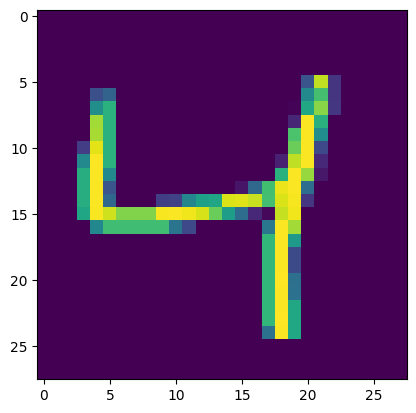

In [27]:
plt.imshow(x_train[2])

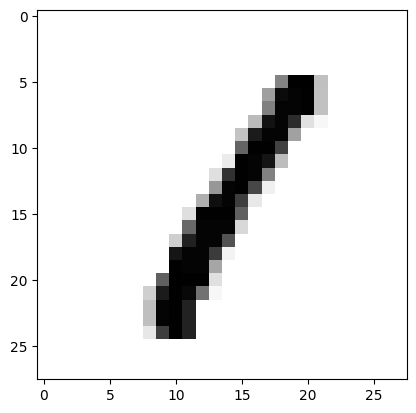

In [34]:
plt.imshow(x_train[3], cmap="binary")

In [29]:
def plot_input_img(i):
    plt.imshow(x_train[i], cmap="binary")
    plt.title(y_train[i])
    plt.show()

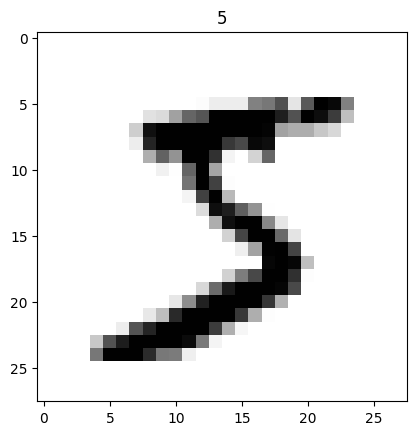

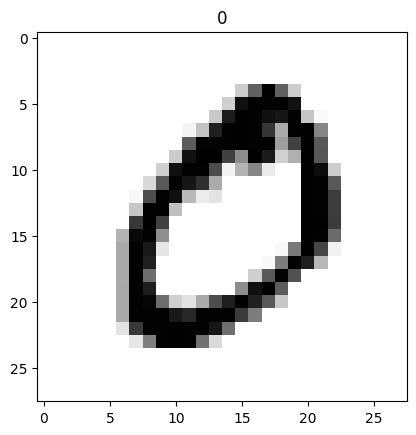

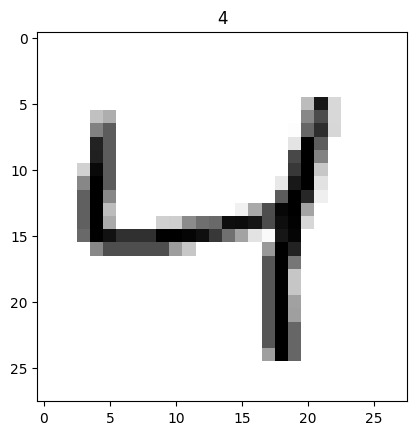

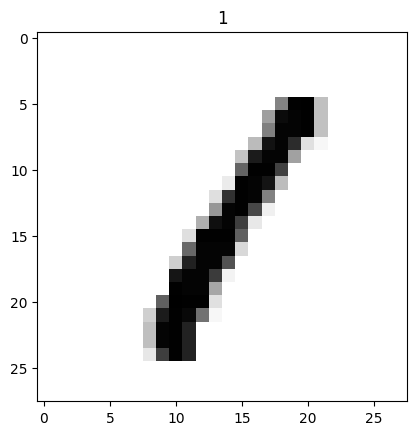

In [35]:
for i in range(4):
    plot_input_img(i)

In [40]:
#normalizing data to range [0,1]

x_train = x_train.astype(np.float32)/255
x_test = x_test.astype(np.float32)/255


# #reshape / expand dim. of images to [28, 28, 1]
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


# #convert classes to one hot vectors [to_categorical =labels → vectors]

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

In [ ]:
x_train.shape


(60000, 28, 28, 1)

In [41]:
model = Sequential()

model.add(Conv2D(32, (3,3), input_shape= (28,28,1), activation='relu'))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D((2,2)))

model.add(Flatten())

model.add(Dropout(0.25))

model.add(Dense(10, activation="softmax"))



In [10]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dropout (Dropout)           (None, 1600)              0

In [42]:
model.compile(optimizer="adam", loss = keras.losses.categorical_crossentropy, metrics=['accuracy'])

In [ ]:

# model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )


In [43]:
#Callback
from keras.callbacks import EarlyStopping, ModelCheckpoint

#Early Stopping
es = EarlyStopping(monitor='val_acc', min_delta=0.01, patience=4, verbose=1)                                  #val_acc - validation accuracy

#Model Checkpoint
mc = ModelCheckpoint("../bestmodel.h5", monitor="val_acc", verbose=1, save_best_only=True)

cb = [es, mc]

In [ ]:
his = model.fit(x_train, y_train, epochs=50, validation_split=0.3)

Epoch 1/50


1313/1313 [==============================] - 4s 3ms/step - loss: 0.2142 - accuracy: 0.9361 - val_loss: 0.0858 - val_accuracy: 0.9734
Epoch 2/50
1313/1313 [==============================] - 3s 3ms/step - loss: 0.0721 - accuracy: 0.9777 - val_loss: 0.0613 - val_accuracy: 0.9818
Epoch 3/50
1313/1313 [==============================] - 3s 3ms/step - loss: 0.0536 - accuracy: 0.9830 - val_loss: 0.0492 - val_accuracy: 0.9851
Epoch 4/50
1313/1313 [==============================] - 3s 3ms/step - loss: 0.0428 - accuracy: 0.9870 - val_loss: 0.0467 - val_accuracy: 0.9866
Epoch 5/50
1313/1313 [==============================] - 3s 3ms/step - loss: 0.0379 - accuracy: 0.9886 - val_loss: 0.0435 - val_accuracy: 0.9867
Epoch 6/50
1313/1313 [==============================] - 3s 3ms/step - loss: 0.0318 - accuracy: 0.9895 - val_loss: 0.0369 - val_accuracy: 0.9887
Epoch 7/50
1313/1313 [==============================] - 3s 3ms/step - loss: 0.0277 - accuracy: 0.9905 - val_loss: 0.0412 - val_accurac